In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt
from astropy.io import fits
from sklearn.cluster import KMeans
import sys
import os
import lightkurve as lk
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("star_functions.py"), '..')))
import star_functions as nana

/Users/natsuki/Projects/hogg_research/venv/lib/python3.9/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
fn = "/Users/natsuki/Projects/hogg_research/hoggnation/oscillator_catalog/good_parents_fit.fits"
with fits.open(fn) as hdu_list:
    print(hdu_list.info())
    data = hdu_list[1].data
    header = hdu_list[1].header
print(len(data), header)

Filename: /Users/natsuki/Projects/hogg_research/hoggnation/oscillator_catalog/good_parents_fit.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     21   1438R x 6C   [K, 12A, D, D, K, 65D]   
None
1438 XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  564 / length of dimension 1                          NAXIS2  =                 1438 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    6 / number of table fields                         TTYPE1  = 'parent_mode_id'                              

In [15]:
all_kics = data['star_id']
print(all_kics[100:250])

['KIC008097825' 'KIC007380537' 'KIC008523194' 'KIC007091476'
 'KIC100002739' 'KIC002996347' 'KIC010847118' 'KIC004737267'
 'KIC004737267' 'KIC004737267' 'KIC004737267' 'KIC004737267'
 'KIC004737267' 'KIC009784371' 'KIC008490027' 'KIC011071207'
 'KIC005567438' 'KIC010710755' 'KIC010710755' 'KIC010710755'
 'KIC003542573' 'KIC007119080' 'KIC005080652' 'KIC005080652'
 'KIC005080652' 'KIC005080652' 'KIC005080652' 'KIC008314879'
 'KIC006182019' 'KIC011200185' 'KIC004249218' 'KIC009179806'
 'KIC010156064' 'KIC009451096' 'KIC011403776' 'KIC011403776'
 'KIC005390351' 'KIC004544587' 'KIC010274218' 'KIC010274244'
 'KIC010274244' 'KIC010274244' 'KIC010274244' 'KIC010274244'
 'KIC010274244' 'KIC007220320' 'KIC007220320' 'KIC008086234'
 'KIC008086234' 'KIC005858519' 'KIC009306369' 'KIC002162994'
 'KIC006694186' 'KIC006694186' 'KIC006694186' 'KIC006694186'
 'KIC006694186' 'KIC100003421' 'KIC005458880' 'KIC005296276'
 'KIC009178425' 'KIC010216186' 'KIC010789273' 'KIC008569819'
 'KIC007129465' 'KIC0071

In [17]:
mask = data['star_id'] == 'KIC005878836'  
matching = data[mask]

parent_mode_ids = matching['parent_mode_id']
print(parent_mode_ids)

[27295]


kic_id KIC005878836 freq 2.8177893752241117
starting to download data for KIC005878836
KIC005878836 is long cadence
nana.get_kepler_data() took 1.4625861644744873 seconds
og freq 2.8177893752241117 new freq 2.8177923839933516


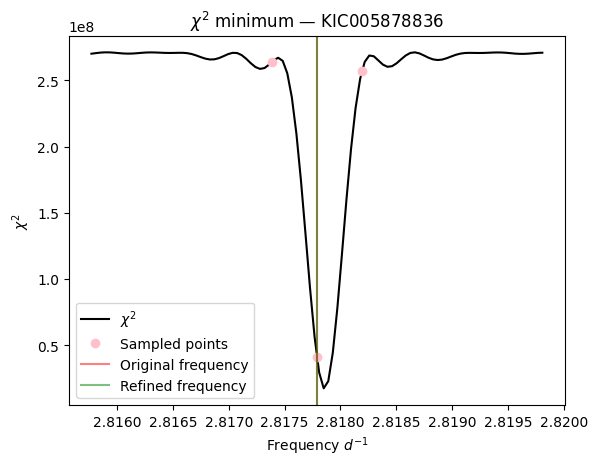

(2.8177923839933516,
 array([ 9.96188412e-01,  5.78056024e-03, -7.52372553e-04, -1.59233077e-02,
        -2.83024300e-02,  2.20284023e-04,  3.37673181e-04,  1.78580347e-03,
        -3.77099174e-03, -3.63515065e-04,  3.20978726e-04,  1.34714099e-03,
        -1.88963643e-04, -1.35364088e-04, -2.30963680e-05,  9.76606974e-05,
         1.26307836e-04, -8.52642105e-06,  8.26675634e-06, -2.11365817e-06,
        -4.83573470e-05, -3.34055945e-05,  1.44340567e-05,  6.07641782e-05,
        -5.08745800e-05, -1.89374072e-05, -4.46360180e-05,  3.03881747e-05,
        -5.59056653e-06,  3.95585975e-05, -1.57573891e-05, -1.05626512e-04,
        -4.74540611e-04, -1.48997948e-03,  1.44089856e-04,  2.82770454e-04,
         3.22802867e-05, -4.50827737e-05,  1.07541125e-05, -2.37770708e-04,
         1.35627450e-04, -3.94826107e-05,  4.12758267e-05,  5.40108602e-06,
        -3.81588497e-06, -8.29836168e-06, -1.07645700e-05, -2.26228688e-05,
         5.62019575e-05, -2.53514399e-06,  8.66939731e-05,  3.42001

In [18]:
nana.fit_fourier_series_to_mode(27295, 32, True)

In [ ]:
0.6299412024490911
0.6299478485840716